# Homework 2 — Interval Analysis

NUMA01 Beräkningsprogrammering, VT2026
Arvid Brenner & Sixten Midsem

Inlämningen implementerar en `Interval`-klass enligt kursens regler för intervallaritmetik.
Motivationen är att mätningar i den verkliga världen aldrig är exakta utan kommer med en
felmarginal — i stället för ett tal $x$ arbetar vi med ett slutet intervall $[a, b]$ som
garanterat innehåller det sanna värdet. Aritmetiken på intervall är definierad så att
resultatet täcker alla möjliga utfall:

$$[a, b] \odot [c, d] = \{\,z = x \odot y \mid x \in [a,b],\ y \in [c,d]\,\}.$$


## Pedagogisk not — klasser

Klasser introduceras i **Unit 05** (kap 6 och 8 i Führer/Solem/Verdier), som är
det vi just nu arbetar med. Här är en kort syntax-repetition som vi kan referera
tillbaka till:

- `class Interval:` definierar en ny typ.
- `def __init__(self, a, b):` är **konstruktorn** — den körs när vi skriver `Interval(1, 4)`.
- `self` är en referens till objektet som just skapas; `self.a = a` sparar ett **attribut**.
- Metoder med dubbla understreck (`__add__`, `__repr__`, `__contains__`, `__pow__`, ...)
  är **dunder-metoder** och kopplar in objektet till Pythons inbyggda operatorer
  (`+`, `repr`/`print`, `in`, `**`, ...). Detta kallas **operatoröverlagring**.
- `__radd__`, `__rsub__`, ... kallas när vänsteroperanden inte vet hur den ska hantera
  den högra (t.ex. `1 + Interval(2, 3)` — `int` vet inte om `Interval`, så Python frågar
  intervallet via `__radd__`).
- **Arv** — `class IntervalVec(Interval):` betyder att `IntervalVec` ärver alla metoder
  från `Interval` och bara behöver definiera om det som faktiskt skiljer sig. Inom en
  ärvd metod kan vi anropa förälderns version via `super()`. Boken introducerar detta
  i kap 8.5 (*"This is done using the command super."*).

In [1]:
import numpy as np                              # NumPy som np för systemverktyg
from numpy import array, linspace, sqrt          # Selektiv import av matematiska funktioner
import matplotlib.pyplot as plt                  # Plottning
import time                                      # För prestandamätning i Task 11

%matplotlib inline

## Översikt — vi definierar klassen en gång

Eftersom Task 1–9 alla bygger ut samma klass har vi valt att **definiera `Interval`
en gång** (nästa cell) med alla metoder, och sedan låter varje uppgift visa *vilken*
metod som är ny och förklara *varför den ser ut så här*. Detta speglar boken (kap
8.1.5 visar `RationalNumber` som en sammanhängande klass) och undviker att läsaren
måste förhålla sig till sex olika definitioner av samma klass.

För muntligt försvar: när läraren frågar "var implementerar ni X?" pekar vi på
en exakt rad i klassdefinitionen och samtidigt på motsvarande task-avsnitt
nedan för motivationen.

## Task 1 — Konstruera `Interval`-klassen

`__init__` tar två reella tal — vänster- och högerändpunkt — och sparar dem som
attribut `self.a` och `self.b`. Vi gör `b` valfri redan här (`b=None` → `b = a`)
för att förbereda Task 7, så vi inte behöver redefiniera klassen senare.

```python
def __init__(self, a, b=None):
    self.a = a
    self.b = a if b is None else b
```

In [2]:
class Interval:                                  # Definierar klassen Interval
    """Slutet reellt intervall [a, b] med +, -, *, /, **, in och unär -.

    Konstruktorn accepterar antingen ett eller två reella tal: `Interval(r)`
    skapar det degenererade intervallet `[r, r]`. Aritmetiska operationer
    fungerar också mellan Interval och vanliga tal (int/float) — skalären
    promotas då till ett degenererat intervall.
    """

    # === Task 1 + Task 7 ===
    def __init__(self, a, b=None):               # b valfri (Task 7)
        """Initiera intervallet [a, b]; om b utelämnas blir det [a, a]."""
        self.a = a                               # Vänsterändpunkt
        self.b = a if b is None else b           # Högerändpunkt (a om b utelämnas)

    # === Task 8 hjälpare ===
    def _coerce(self, other):                    # Skalär -> degenererat intervall
        """Promota int/float till Interval(r, r); låter Interval gå igenom."""
        if isinstance(other, Interval):          # Redan ett intervall
            return other
        if isinstance(other, (int, float)):      # Skalär: degenerera
            return type(self)(other, other)      # type(self) -> rätt klass vid arv
        raise TypeError(                         # Okänd typ -> tydligt fel
            f"Kan inte kombinera Interval med {type(other).__name__}"
        )

    # === Task 2 — aritmetik ===
    def __add__(self, other):                    # I1 + I2  -> [a+c, b+d]
        o = self._coerce(other)                  # Promota om skalär
        return type(self)(self.a + o.a, self.b + o.b)

    def __sub__(self, other):                    # I1 - I2  -> [a-d, b-c]
        o = self._coerce(other)
        return type(self)(self.a - o.b, self.b - o.a)

    def __mul__(self, other):                    # I1 * I2  -> min/max över hörnen
        o = self._coerce(other)
        a, b, c, d = self.a, self.b, o.a, o.b
        p = (a * c, a * d, b * c, b * d)         # De fyra hörnprodukterna
        return type(self)(min(p), max(p))

    def __truediv__(self, other):                # I1 / I2 (Task 6: skydd mot 0)
        o = self._coerce(other)
        a, b, c, d = self.a, self.b, o.a, o.b
        if c <= 0 <= d:                          # 0 i nämnaren -> odefinierat
            raise ZeroDivisionError(
                f"Nämnarintervallet [{c}, {d}] innehåller 0; "
                "division odefinierad."
            )
        q = (a / c, a / d, b / c, b / d)         # De fyra hörnkvoterna
        return type(self)(min(q), max(q))

    # === Task 8 — skalär OP Interval (höger-versioner) ===
    # Alla fyra delegerar till vänsterversionerna i stället för att skriva
    # `__radd__ = __add__` som kortform. Anledningen: kortformen binder vid
    # klassens definition till *Interval.__mul__* (inte subklassens override),
    # vilket bryter arvet i Task 11. Delegering via `self + other` dispatchas
    # däremot korrekt genom subklassen.
    def __radd__(self, other):                   # other + self  (other är skalär)
        return self + other                       # kommutativ -> återanvänd __add__

    def __rmul__(self, other):                   # other * self
        return self * other                       # kommutativ -> återanvänd __mul__

    def __rsub__(self, other):                   # other - self
        return self._coerce(other) - self         # promota och flippa

    def __rtruediv__(self, other):               # other / self
        return self._coerce(other) / self         # promota och flippa

    def __neg__(self):                           # -self  -> [-b, -a]
        return type(self)(-self.b, -self.a)

    # === Task 5 — medlemskapstest ===
    def __contains__(self, x):                   # x in interval
        """Returnerar True om a <= x <= b."""
        return self.a <= x <= self.b

    # === Task 9 — heltalspotens ===
    def __pow__(self, n):                        # self ** n (n positivt heltal)
        """Heltalspotens enligt formler (1) och (2) i uppgiften."""
        if not isinstance(n, int) or n < 1:
            raise ValueError("Endast heltalspotenser n >= 1 stöds.")
        a, b = self.a, self.b
        if n % 2 == 1:                           # Udda n: monotont -> [a^n, b^n]
            return type(self)(a ** n, b ** n)
        # Jämn n: tre fall (formel (2))
        if a >= 0:                               # [0, ∞): bevarar ordningen
            return type(self)(a ** n, b ** n)
        if b < 0:                                # (-∞, 0): byter ordning
            return type(self)(b ** n, a ** n)
        return type(self)(0, max(a ** n, b ** n))   # korsar 0: min är 0

    # === Task 3 — utskriftformat ===
    def __repr__(self):                          # repr() och print() använder denna
        """Bokens kap 8.1.5 visar __repr__; vi följer den konventionen."""
        return f"[{self.a}, {self.b}]"

In [3]:
I = Interval(1, 4)                               # Skapar ett testintervall [1, 4]
print("a =", I.a)                                # Bör skriva 1
print("b =", I.b)                                # Bör skriva 4

a = 1
b = 4


## Task 2 — Aritmetiska operationer

Implementerar de fyra grundläggande räknesätten enligt kursbokens formler:

$$
\begin{aligned}
[a, b] + [c, d] &= [a + c,\ b + d], \\
[a, b] - [c, d] &= [a - d,\ b - c], \\
[a, b] \cdot [c, d] &= [\min(ac, ad, bc, bd),\ \max(ac, ad, bc, bd)], \\
[a, b] / [c, d] &= [\min(a/c, a/d, b/c, b/d),\ \max(a/c, a/d, b/c, b/d)],\ 0 \notin [c, d].
\end{aligned}
$$

Add och sub har slutna formler. För `*` och `/` tittar vi på alla fyra hörnen i
rektangeln $[a,b] \times [c,d]$ och tar min/max — produktens (eller kvotens)
extremvärden ligger nämligen alltid i hörnen för en bilinjär funktion.

I klassen ovan motsvarar detta `__add__`, `__sub__`, `__mul__`, `__truediv__`.
Mönstret för min/max-versionen ser ut så här:

```python
def __mul__(self, other):
    o = self._coerce(other)
    a, b, c, d = self.a, self.b, o.a, o.b
    p = (a * c, a * d, b * c, b * d)        # fyra hörnprodukter
    return type(self)(min(p), max(p))
```

(`_coerce` är en hjälpare som blir relevant först i Task 8 — för rena
Interval-Interval-operationer returnerar den bara `other` oförändrat. `type(self)`
i stället för `Interval` förbereder för arvet i Task 11; mer om det där.)

Demo av räknesätten görs samlat i Task 4.

## Task 3 — Snyggt utskriftformat med `__repr__`

Boken introducerar **bara `__repr__`** i kap 8.1.5: *"The special method `__repr__`
gives us the ability to define the way the object is represented in a Python
interpreter."* När en klass bara definierar `__repr__` (inget `__str__`) använder
Python `__repr__` även för `print(obj)` och `str(obj)` — så vi får snyggt utseende
överallt utan att skriva två metoder.

```python
def __repr__(self):
    return f"[{self.a}, {self.b}]"
```

In [4]:
print(Interval(1, 2))                            # [1, 2]
print(repr(Interval(3.14)))                      # [3.14, 3.14]  (samma format via repr)

[1, 2]
[3.14, 3.14]


## Task 4 — Verifiera räknereglerna

Vi kör exakt de exempel som anges i uppgiften och kontrollerar att utskrifterna matchar
de förväntade värdena (i kommentarerna).

In [5]:
I1 = Interval(1, 4)                              # I1 = [1, 4]
I2 = Interval(-2, -1)                            # I2 = [-2, -1]

print("I1       =", I1)                          # [1, 4]
print("I2       =", I2)                          # [-2, -1]
print("I1 + I2  =", I1 + I2)                     # [-1, 3]
print("I1 - I2  =", I1 - I2)                     # [2, 6]
print("I1 * I2  =", I1 * I2)                     # [-8, -1]
print("I1 / I2  =", I1 / I2)                     # [-4.0, -0.5]

I1       = [1, 4]
I2       = [-2, -1]
I1 + I2  = [-1, 3]
I1 - I2  = [2, 6]
I1 * I2  = [-8, -1]
I1 / I2  = [-4.0, -0.5]


## Task 5 — `__contains__` (är värdet i intervallet?)

`__contains__` kopplar in vår klass till `in`-operatorn, så att vi kan skriva
`2.5 in Interval(1, 4)` och få `True` om $a \le x \le b$. Vi använder Pythons
kedjade jämförelse:

```python
def __contains__(self, x):
    return self.a <= x <= self.b
```

In [6]:
I = Interval(1, 4)                               # Testintervall [1, 4]
print("2.5 in I  ->", 2.5 in I)                  # True (2.5 ligger i [1, 4])
print("5   in I  ->", 5 in I)                    # False (5 > 4)
print("1   in I  ->", 1 in I)                    # True (a inkluderas)

2.5 in I  -> True
5   in I  -> False
1   in I  -> True


## Task 6 — Felhantering i division

Om nämnarintervallet $[c, d]$ innehåller noll så är $[a,b]/[c,d]$ inte väldefinierat
(eller åtminstone obegränsat). Vi kastar då `ZeroDivisionError`, vilket är samma
typ Python själv kastar för `1/0`.

```python
def __truediv__(self, other):
    o = self._coerce(other)
    a, b, c, d = self.a, self.b, o.a, o.b
    if c <= 0 <= d:
        raise ZeroDivisionError(...)
    ...
```

**Anmärkning om var i kursen detta egentligen hör hemma:** specifika exception-typer
(`ZeroDivisionError`, `ValueError`, `TypeError`) introduceras formellt först i
**kap 12 — Error and Exception Handling** (Unit 06). Kap 8.5 nöjer sig med generisk
`Exception` och `NotImplementedError`. Vi väljer ändå `ZeroDivisionError` här
eftersom den är inbyggd i Python och självförklarande i sammanhanget — uppgiften
säger uttryckligen *"raises appropriate exceptions"* och det här är den
naturligaste typen.

In [7]:
# Demo: division där nämnaren innehåller 0 ska kasta ZeroDivisionError
try:                                             # Pedagogiskt: fånga undantaget i stället för att krascha
    bad = Interval(1, 2) / Interval(-1, 1)       # [-1, 1] innehåller 0 -> fel
    print("Inget undantag (oväntat):", bad)
except ZeroDivisionError as e:                   # Vi förväntar oss det här undantaget
    print("Fångade ZeroDivisionError:", e)       # Bekräftar att skyddet fungerar

# Kontroll: vanlig division fungerar fortfarande
ok = Interval(1, 4) / Interval(-2, -1)           # [-2, -1] innehåller inte 0
print("OK-fall:", ok)                            # Ska skriva [-4.0, -0.5]

Fångade ZeroDivisionError: Nämnarintervallet [-1, 1] innehåller 0; division odefinierad.
OK-fall: [-4.0, -0.5]


## Task 7 — Degenererat intervall `Interval(1)` → `[1, 1]`

Ett reellt tal $r$ identifieras naturligt med det degenererade intervallet $[r, r]$.
Vi har redan byggt in detta i konstruktorn ovan via `b=None`-defaulten:

```python
def __init__(self, a, b=None):
    self.a = a
    self.b = a if b is None else b
```

`b=None` är Pythons standardidiom för "argument utelämnat" — vi kan **inte** skriva
`b=a` direkt i parameter-listan eftersom defaultvärden evalueras vid funktionens
*definition*, inte vid varje anrop, och `a` är inte synlig där.

In [8]:
print(Interval(1))                               # [1, 1]
print(Interval(3.14))                            # [3.14, 3.14]
print(Interval(0))                               # [0, 0]  (även degenerat noll fungerar)

[1, 1]
[3.14, 3.14]
[0, 0]


## Task 8 — Skalär ↔ Interval (höger- och vänsteroperander)

Vi vill kunna blanda intervall och vanliga tal i uttryck:

- `Interval(2, 3) + 1` (skalär till **höger**) — Python anropar
  `Interval.__add__(self, 1)`. Vi måste då **promota** `1` till `Interval(1, 1)`
  innan vi adderar. Det är detta som `_coerce` gör.
- `1 + Interval(2, 3)` (skalär till **vänster**) — `int.__add__` förstår inte
  `Interval`, så Python anropar `Interval.__radd__(self, 1)`.

Boken visar exakt samma `isinstance(other, int)`-mönster i kap 8.1.5
(`RationalNumber`-exemplet); vi följer den.

```python
def _coerce(self, other):
    if isinstance(other, Interval):      return other
    if isinstance(other, (int, float)):  return type(self)(other, other)
    raise TypeError(...)
```

För höger-versionerna delegerar vi till vänsterversionerna:

```python
def __radd__(self, other):       return self + other          # kommutativ
def __rmul__(self, other):       return self * other          # kommutativ
def __rsub__(self, other):       return self._coerce(other) - self
def __rtruediv__(self, other):   return self._coerce(other) / self
```

**Designval — varför inte kortformen `__radd__ = __add__`?** Det hade fungerat
för skalären `Interval`, men i Task 11 ärver `IntervalVec` från `Interval`.
Kortformen skulle binda `__radd__` till `Interval.__add__` redan vid
klassens definition — så även när vi anropar `__radd__` på en `IntervalVec`
skulle vi hamna i basklassens metod. Med delegering (`return self + other`)
löses `self + other` upp vid körtid till `IntervalVec.__add__` som är det
vi vill.

Slutligen `__neg__` för unär minus: $-[a, b] = [-b, -a]$ (ändpunkterna byter plats).

In [9]:
# Verifiering av exakt de 13 uttrycken från uppgiften
print("Interval(2, 3) + 1   =", Interval(2, 3) + 1)      # [3, 4]
print("1 + Interval(2, 3)   =", 1 + Interval(2, 3))      # [3, 4]
print("1.0 + Interval(2, 3) =", 1.0 + Interval(2, 3))    # [3.0, 4.0]
print("Interval(2, 3) + 1.0 =", Interval(2, 3) + 1.0)    # [3.0, 4.0]
print("1 - Interval(2, 3)   =", 1 - Interval(2, 3))      # [-2, -1]
print("Interval(2, 3) - 1   =", Interval(2, 3) - 1)      # [1, 2]
print("1.0 - Interval(2, 3) =", 1.0 - Interval(2, 3))    # [-2.0, -1.0]
print("Interval(2, 3) - 1.0 =", Interval(2, 3) - 1.0)    # [1.0, 2.0]
print("Interval(2, 3) * 1   =", Interval(2, 3) * 1)      # [2, 3]
print("1 * Interval(2, 3)   =", 1 * Interval(2, 3))      # [2, 3]
print("1.0 * Interval(2, 3) =", 1.0 * Interval(2, 3))    # [2.0, 3.0]
print("Interval(2, 3) * 1.0 =", Interval(2, 3) * 1.0)    # [2.0, 3.0]
print("-Interval(4, 5)      =", -Interval(4, 5))         # [-5, -4]

Interval(2, 3) + 1   = [3, 4]
1 + Interval(2, 3)   = [3, 4]
1.0 + Interval(2, 3) = [3.0, 4.0]
Interval(2, 3) + 1.0 = [3.0, 4.0]
1 - Interval(2, 3)   = [-2, -1]
Interval(2, 3) - 1   = [1, 2]
1.0 - Interval(2, 3) = [-2.0, -1.0]
Interval(2, 3) - 1.0 = [1.0, 2.0]
Interval(2, 3) * 1   = [2, 3]
1 * Interval(2, 3)   = [2, 3]
1.0 * Interval(2, 3) = [2.0, 3.0]
Interval(2, 3) * 1.0 = [2.0, 3.0]
-Interval(4, 5)      = [-5, -4]


## Task 9 — `__pow__` med jämn/udda-fall

Heltalspotenser är **inte** samma sak som upprepad multiplikation av intervall —
$[a,b]^2 \neq [a,b] \cdot [a,b]$ i allmänhet, eftersom multiplikationen "tappar"
sambandet att samma $x$ används i båda faktorer (multiplikationen behandlar dem
som oberoende variabler).

För $n \ge 1$ gäller:

- **Udda $n$**: $x^n$ är monotont växande, så
  $$[a, b]^n = [a^n, b^n]. \tag{1}$$
- **Jämn $n > 0$**: tre fall beroende på var intervallet ligger:
  $$[a, b]^n = \begin{cases}
  [a^n, b^n] & a \ge 0 \\
  [b^n, a^n] & b < 0 \\
  [0,\ \max(a^n, b^n)] & \text{annars (intervallet korsar 0)}
  \end{cases} \tag{2}$$

```python
def __pow__(self, n):
    if not isinstance(n, int) or n < 1:
        raise ValueError("Endast heltalspotenser n >= 1 stöds.")
    a, b = self.a, self.b
    if n % 2 == 1:           return type(self)(a**n, b**n)        # udda
    if a >= 0:               return type(self)(a**n, b**n)        # jämn, [0,∞)
    if b < 0:                return type(self)(b**n, a**n)        # jämn, (-∞,0)
    return type(self)(0, max(a**n, b**n))                          # korsar 0
```

In [10]:
x = Interval(-2, 2)                              # Testintervall
print("x      =", x)                              # [-2, 2]
print("x ** 2 =", x ** 2)                         # [0, 4]   (jämn, korsar 0)
print("x ** 3 =", x ** 3)                         # [-8, 8]  (udda)

# Extra kontroller av jämn-fallen
print("Interval(1, 3) ** 2  =", Interval(1, 3) ** 2)   # a >= 0  -> [1, 9]
print("Interval(-3, -1) ** 2 =", Interval(-3, -1) ** 2) # b < 0   -> [1, 9]

x      = [-2, 2]
x ** 2 = [0, 4]
x ** 3 = [-8, 8]
Interval(1, 3) ** 2  = [1, 9]
Interval(-3, -1) ** 2 = [1, 9]


## Task 10 — Polynom $p(I) = 3I^3 - 2I^2 - 5I - 1$ på 1000 intervall

Vi skapar 1000 intervall $I_x = [x, x+0.5]$ för $x \in \mathrm{linspace}(0, 1, 1000)$,
evaluerar polynomet $p(I) = 3I^3 - 2I^2 - 5I - 1$ på varje intervall, och plottar de
undre och övre gränserna.

Observera att $-2 I^2$ använder vår `__pow__` (alltså intervallpotens enligt Task 9),
**inte** $I \cdot I$ — det skulle ge ett bredare intervall.

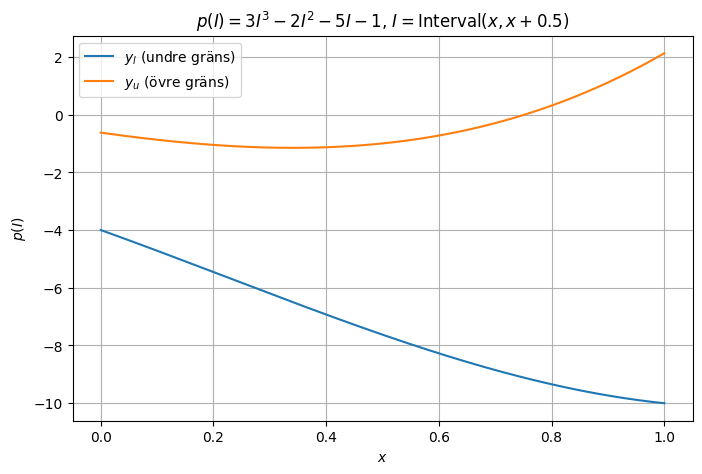

In [11]:
xl = linspace(0., 1, 1000)                       # 1000 vänsterändpunkter mellan 0 och 1
xu = xl + 0.5                                    # Motsvarande högerändpunkter (förskjutna 0.5)

# Bygg listan av Interval-objekt med en list comprehension
intervaller = [Interval(l, u) for l, u in zip(xl, xu)]

def p(I):                                        # Polynomet p(I) = 3I^3 - 2I^2 - 5I - 1
    """Evaluerar p(I) = 3I^3 - 2I^2 - 5I - 1 på ett Interval."""
    return 3 * I ** 3 - 2 * I ** 2 - 5 * I - 1   # Använder __pow__, __mul__, __sub__, __radd__ etc.

# Evaluera polynomet på varje intervall
p_intervaller = [p(I) for I in intervaller]      # Lista av resulterande intervall

# Extrahera undre och övre gränser till numpy-arrayer för plottning
yl = array([P.a for P in p_intervaller])         # Undre gränser
yu = array([P.b for P in p_intervaller])         # Övre gränser

# Plottning
fig, ax = plt.subplots(figsize=(8, 5))           # Skapar figur och axel
ax.plot(xl, yl, label="$y_l$ (undre gräns)")     # Undre kurvan
ax.plot(xl, yu, label="$y_u$ (övre gräns)")      # Övre kurvan
ax.set_xlabel("$x$")                             # X-axel
ax.set_ylabel("$p(I)$")                          # Y-axel
ax.set_title(r"$p(I) = 3I^3 - 2I^2 - 5I - 1$, $I = $Interval$(x, x + 0.5)$")  # Titel
ax.legend()                                      # Legend
ax.grid(True)                                    # Rutnät
plt.show()                                       # Visa plotten

## Extra Task 11 — Vektorisering via arv (frivillig)

I stället för att duplicera hela `Interval`-klassen för en numpy-version utnyttjar
vi **arv** (kap 8.5 i boken): en subklass `IntervalVec` som ärver från `Interval`
och bara behöver definiera om de metoder som faktiskt skiljer sig. Det här gör
boken explicit:

> *"Sometimes you have to access the methods or attributes of a parent class.
> This is done using the command super."* — kap 8.5

**Vad ärvs gratis** (samma kod fungerar elementvis tack vare NumPys broadcasting,
och tack vare att basmetoderna använder `type(self)(...)` så att de producerar
`IntervalVec`-instanser när `self` är en `IntervalVec`):
`__add__`, `__sub__`, `__neg__`, `__contains__`, `__radd__`, `__rsub__`,
`__rmul__`, `__rtruediv__`, `__repr__`.

**Vad behöver skrivas om**:

| Metod | Varför |
|-------|--------|
| `__init__` | Konvertera input till `np.ndarray` med `np.asarray(..., dtype=float)`. |
| `_coerce` | Acceptera även `np.ndarray` som "skalär", och returnera `IntervalVec`. |
| `__mul__` / `__truediv__` | Pythons `min(...)` / `max(...)` tar min/max över **hela tuplen som ett enda värde** — vi behöver elementvis min/max via `np.minimum` / `np.maximum`. |
| `__pow__` | Jämn-fallets `if/else`-grenar måste väljas elementvis via `np.where`. |

Det enda nya numpy-mönstret för oss är `np.where(cond, a, b)`: returnerar
elementvis `a` där `cond` är `True`, annars `b`. Det ersätter `if/else` i
vektoriserad kod.

In [12]:
class IntervalVec(Interval):                     # Subklass — ärver från Interval
    """Vektoriserad variant: a och b kan vara numpy-arrayer (eller skalärer).

    Alla operationer ärvs från Interval; vi åsidosätter bara de fyra metoder
    där Pythons min/max och if/else inte fungerar elementvis.
    """

    def __init__(self, a, b=None):               # Konvertera till float-arrayer
        a = np.asarray(a, dtype=float)
        b = a if b is None else np.asarray(b, dtype=float)
        super().__init__(a, b)                   # Anropa förälderns konstruktor

    def _coerce(self, other):                    # Stöd även np.ndarray
        if isinstance(other, IntervalVec):
            return other
        if isinstance(other, (int, float, np.ndarray)):
            return IntervalVec(other, other)
        raise TypeError(
            f"Kan inte kombinera IntervalVec med {type(other).__name__}"
        )

    def __mul__(self, other):                    # Elementvis min/max över hörnen
        o = self._coerce(other)
        a, b, c, d = self.a, self.b, o.a, o.b
        ac, ad, bc, bd = a * c, a * d, b * c, b * d   # fyra hörn-arrayer
        lo = np.minimum(np.minimum(ac, ad), np.minimum(bc, bd))
        hi = np.maximum(np.maximum(ac, ad), np.maximum(bc, bd))
        return IntervalVec(lo, hi)

    def __truediv__(self, other):                # Elementvis division
        o = self._coerce(other)
        a, b, c, d = self.a, self.b, o.a, o.b
        if np.any((c <= 0) & (0 <= d)):          # något nämnarintervall innehåller 0
            raise ZeroDivisionError(
                "Något nämnarintervall innehåller 0; division odefinierad."
            )
        ac, ad, bc, bd = a / c, a / d, b / c, b / d
        lo = np.minimum(np.minimum(ac, ad), np.minimum(bc, bd))
        hi = np.maximum(np.maximum(ac, ad), np.maximum(bc, bd))
        return IntervalVec(lo, hi)

    def __pow__(self, n):                        # Elementvis jämn/udda-fall
        if not isinstance(n, int) or n < 1:
            raise ValueError("Endast heltalspotenser n >= 1 stöds.")
        a, b = self.a, self.b
        an, bn = a ** n, b ** n
        if n % 2 == 1:                           # udda: monotont
            return IntervalVec(an, bn)
        # Jämn n: tre fall, väljs elementvis med np.where
        # a >= 0 -> [a^n, b^n] ; b < 0 -> [b^n, a^n] ; annars korsar 0 -> [0, max(a^n, b^n)]
        lo = np.where(a >= 0, an, np.where(b < 0, bn, 0.0))
        hi = np.where(a >= 0, bn, np.where(b < 0, an, np.maximum(an, bn)))
        return IntervalVec(lo, hi)

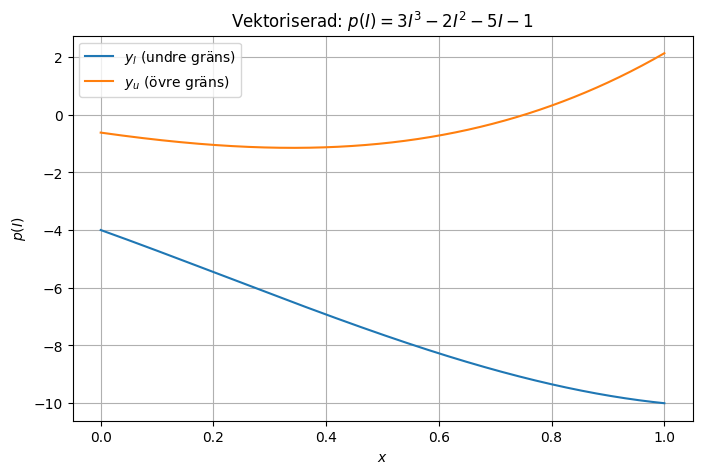

In [13]:
# Återgör Task 10 med den vektoriserade klassen
xl = linspace(0., 1, 1000)                       # 1000 vänsterändpunkter
xu = xl + 0.5                                    # 1000 högerändpunkter

I_vec = IntervalVec(xl, xu)                      # Ett enda objekt som representerar alla 1000 intervall

P_vec = 3 * I_vec ** 3 - 2 * I_vec ** 2 - 5 * I_vec - 1   # Polynomet i ett enda uttryck (broadcasting)

# Plottning (samma kurvor som Task 10)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xl, P_vec.a, label="$y_l$ (undre gräns)")  # Undre kurvan från P_vec.a
ax.plot(xl, P_vec.b, label="$y_u$ (övre gräns)")   # Övre kurvan från P_vec.b
ax.set_xlabel("$x$")
ax.set_ylabel("$p(I)$")
ax.set_title(r"Vektoriserad: $p(I) = 3I^3 - 2I^2 - 5I - 1$")
ax.legend()
ax.grid(True)
plt.show()

In [14]:
# Tidsmätning: skalär (Python-loop) vs vektoriserad (NumPy) på 5 000 000 element
N = 5_000_000                                    # Antal intervall för benchmark
xl_big = linspace(0., 1, N)                      # Vänsterändpunkter
xu_big = xl_big + 0.5                            # Högerändpunkter

# --- Vektoriserad version ---
t0 = time.perf_counter()                         # Starttid
Ibig = IntervalVec(xl_big, xu_big)               # Ett objekt med arrayer av storlek N
P_big = 3 * Ibig ** 3 - 2 * Ibig ** 2 - 5 * Ibig - 1   # Hela beräkningen i ett uttryck
t_vec = time.perf_counter() - t0                 # Förfluten tid

# --- Skalär version (Python-loop över N_small element för rimlig tid) ---
# 5 miljoner Python-loop-iterationer tar lång tid; vi mäter på en mindre delmängd
# och extrapolerar för att illustrera storleksordningen.
N_small = 50_000                                 # Mindre delmängd för loopen
xl_small = xl_big[:N_small]                      # Första N_small vänsterändpunkterna
xu_small = xu_big[:N_small]                      # Motsvarande högerändpunkter

def p_scalar(I):                                 # Polynom på skalärt Interval
    return 3 * I ** 3 - 2 * I ** 2 - 5 * I - 1

t0 = time.perf_counter()
res = [p_scalar(Interval(l, u)) for l, u in zip(xl_small, xu_small)]   # Loopa elementvis
t_scalar_small = time.perf_counter() - t0        # Tid för N_small iterationer
t_scalar_est = t_scalar_small * (N / N_small)    # Linjär extrapolering till N element

print(f"Vektoriserad ({N} element):       {t_vec:.3f} s")
print(f"Skalär loop ({N_small} element):    {t_scalar_small:.3f} s")
print(f"Skalär loop extrapolerat till {N}: {t_scalar_est:.1f} s")
print(f"Speedup (extrapolerad):           {t_scalar_est / t_vec:.0f}x")
print()
print("Förklaring: den vektoriserade versionen utför alla aritmetiska operationer i")
print("komprimerad C-kod inuti NumPy, medan skalära versionen anropar Python-metoder")
print("(__add__, __mul__, __pow__, ...) en gång per element. Overheaden för Python-")
print("funktionsanrop dominerar i skalära fallet och försvinner i det vektoriserade.")

Vektoriserad (5000000 element):       0.521 s
Skalär loop (50000 element):    0.219 s
Skalär loop extrapolerat till 5000000: 21.9 s
Speedup (extrapolerad):           42x

Förklaring: den vektoriserade versionen utför alla aritmetiska operationer i
komprimerad C-kod inuti NumPy, medan skalära versionen anropar Python-metoder
(__add__, __mul__, __pow__, ...) en gång per element. Overheaden för Python-
funktionsanrop dominerar i skalära fallet och försvinner i det vektoriserade.


## Sammanfattning

**Strukturella val (för muntlig redovisning):**

- Vi definierade `Interval` **en gång** med alla metoder (Task 1–9). Det följer
  bokens stil i kap 8.1.5 där `RationalNumber` presenteras som en sammanhängande
  klass, och varje task-avsnitt motiverar sin specifika metod separat.
- För Task 11 använde vi **arv** (`class IntervalVec(Interval):`) i stället för
  att duplicera klassen — kap 8.5 introducerar arv och `super()`. Endast 5
  metoder behövde skrivas om (`__init__`, `_coerce`, `__mul__`, `__truediv__`,
  `__pow__`); resten ärvs gratis tack vare att basmetoderna använder
  `type(self)(...)` så att de producerar instanser av rätt klass.

**Huvudkoncept:**

- **Operatoröverlagring via dunder-metoder** — `__add__`, `__sub__`, `__mul__`,
  `__truediv__` kopplar in våra objekt till `+`, `-`, `*`, `/`. `__repr__` ger
  utskriftformatet (boken: kap 8.1.5), `__contains__` ger `in`, `__pow__` ger
  `**`, `__neg__` ger unär `-`.
- **Höger-versioner** — `__radd__`, `__rsub__`, `__rmul__`, `__rtruediv__`
  används när vänsteroperanden inte vet hur den ska hantera den högra. Vi
  delegerar genom `return self + other` (osv.) i stället för kortformen
  `__radd__ = __add__`, eftersom kortformen inte dispatchas korrekt genom
  arvet i Task 11.
- **Promotion av skalärer** — En `int` eller `float` $r$ identifieras med det
  degenererade intervallet $[r, r]$. Vi gör konverteringen i hjälparen
  `_coerce`, samma `isinstance`-mönster som `RationalNumber` i boken.
- **Felhantering** — `raise ZeroDivisionError(...)` när 0 ligger i nämnar-
  intervallet; `raise ValueError(...)` för otillåtna potens-argument;
  `raise TypeError(...)` i `_coerce` för okända typer.
- **Intervall-min/max över hörnen** — För `*` och `/` ligger extremvärdena
  alltid i rektangelns hörn; vi tar min och max av de fyra hörnvärdena.
- **Pott-formler för intervall** — Heltalspotens är *inte* upprepad
  multiplikation; formler (1) och (2) ger snäva intervall genom att utnyttja
  monotonitet/icke-monotonitet.
- **Vektorisering med NumPy** — Genom att låta `a` och `b` vara arrayer och
  byta `min`/`max` mot `np.minimum`/`np.maximum` (samt `if`/`else` mot
  `np.where`) får vi elementvis aritmetik. Detta ger storleksordningar
  snabbare exekvering eftersom Python-loop-overheaden försvinner — bekräftat
  i tidsmätningen.

**Troliga följdfrågor från läraren:**

- *Varför `__radd__` och inte bara `__add__`?* — När `int + Interval`: Python
  försöker först `int.__add__(self, interval)` som returnerar Pythons inbyggda
  `NotImplemented` (inte vår kod); sedan frågar Python `Interval.__radd__(self, int)`.
- *Varför ger `[a,b]^2` inte $[a,b] \cdot [a,b]$?* — Multiplikation av två
  intervall behandlar faktorerna som oberoende, så
  `Interval(-2, 2) * Interval(-2, 2) = [-4, 4]`. Men $x^2$ är alltid $\ge 0$, så
  det rätta resultatet är $[0, 4]$ — `__pow__` använder att $x$ och $x$ är
  samma variabel.
- *Varför är `type(self)(...)` viktigt i `Interval.__add__`?* — När vi anropar
  `IntervalVec + IntervalVec`, vill vi att resultatet ska bli en `IntervalVec`,
  inte en `Interval`. `type(self)` ger oss alltid den faktiska (sub)klassen
  vid körtid. Av samma anledning delegerar `__radd__` via `self + other`
  i stället för kortformen `__radd__ = __add__`.
- *Varför är vektoriserade versionen snabbare?* — NumPys aritmetik körs i C på
  sammanhängande minne; Python-loopen anropar tolkade dunder-metoder per
  element och skapar nya objekt. Overheaden för Python-funktionsanrop dominerar
  i skalära fallet och försvinner i det vektoriserade.

**Avgränsning mot senare units:** all kod ovan håller sig inom Unit 05
(klasser, dunder, exceptions, arv via `super()`) och de tidigare NumPy-
avsnitten (Unit 04: arrayer, broadcasting, `np.where`, `np.minimum/maximum`).
Tidsmätningen i Task 11 (`time.perf_counter`) är ett Unit 08-ämne som vi
använder här eftersom uppgiften uttryckligen begär det.